In [1]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import sys
sys.path.append('../')
from src.trajectory_utils import reconstruct_trajectory_from_canonical_pieces

In [2]:
#names = ['only_persistent']
names = ['straight_helix']


embs,mkvs = list(),list()
for name in names:
    # Paths to data from embed_and_cluster.py
    with open("../data/toy_model/processed/embedding_"+name+".pkl", "rb") as f:
            embs.append(pickle.load(f))
    with open("../data/toy_model/processed/markov_"+name+".pkl", "rb") as f:
            mkvs.append(pickle.load(f))
taus = [10]
for i in range(names.__len__()):
        mkvs[i].tau = taus[i]
        mkvs[i].make_transition_matrix()

In [3]:
# Run a trajectory in the markov space:
i = 0
N_trajectories=embs[i].Y_translated.shape[0]
simul_traj = list()
for _ in range(N_trajectories):
    mkv_trajectory = mkvs[i].build_trajectory(T_tot = embs[0].T)
    pieces = np.array([embs[i].pick_random_trajectory_in_cluster(n) for n in mkv_trajectory])
    simul_traj.append(reconstruct_trajectory_from_canonical_pieces(pieces,embs[i].K))
simul_traj=np.array(simul_traj)

In [8]:
traj = mkvs[0].build_trajectory(T_tot = 1000)
pieces = np.array([embs[i].pick_random_trajectory_in_cluster(n) for n in traj])
xyz = reconstruct_trajectory_from_canonical_pieces(pieces,embs[i].K)
count = dict(Counter(traj))
print(sum(count.values()))
print(count[0])
print(count[1])

101
58
29


Text(0.5, 0.92, 'generated trajectory')

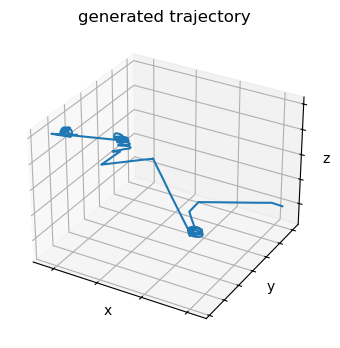

In [9]:
fig,ax = plt.subplots(figsize=(4,4),subplot_kw={'projection':'3d'})
ax.plot(xyz[:,0],xyz[:,1],xyz[:,2])
ax.set_xticklabels([])
ax.set_zticklabels([])
ax.set_yticklabels([])
ax.set_xlabel('x',labelpad=-10)
ax.set_ylabel('y',labelpad=-10)
ax.set_zlabel('z',labelpad=-10)

ax.set_title('generated trajectory')
#fig.savefig('generated_trajectory.svg',bbox_inches='tight')

In [10]:
def compute_acf(trajs: np.ndarray,
                kind: str = "velocity",
                normalize: bool = True,
                demean: bool = True,
                max_lag: int | None = None):
    """
    Autocorrelation function from 3D trajectories.

    Parameters
    ----------
    trajs : (N, T, 3) float array
    kind : {"velocity", "position"}
        - "velocity": VACF of v(t) = r(t+1)-r(t), i.e., <v(t)·v(t+tau)>
        - "position": ACF of positions (optionally demeaned), i.e., <r'(t)·r'(t+tau)>
    normalize : bool
        Divide by C(0) so that ACF[0] = 1.
    demean : bool
        For position ACF only: subtract mean position before computing correlations.
        (Ignored for velocity ACF; velocity has near-zero mean for typical random walks.)
    max_lag : int or None
        Compute ACF up to this lag. Default: T-2 for velocity, T-1 for position.

    Returns
    -------
    tau : (L,) int array
        Lags.
    acf : (L,) float array
        Autocorrelation vs lag.
    """
    if trajs.ndim != 3 or trajs.shape[-1] != 3:
        raise ValueError("trajs must have shape (N, T, 3)")
    N, T, _ = trajs.shape

    if kind not in {"velocity", "position"}:
        raise ValueError("kind must be 'velocity' or 'position'")

    if kind == "velocity":
        v = np.diff(trajs, axis=1)  # (N, T-1, 3)
        Tv = v.shape[1]
        if max_lag is None:
            max_lag = Tv - 1
        max_lag = int(min(max_lag, Tv - 1))
        tau = np.arange(0, max_lag + 1, dtype=int)

        acf = np.empty_like(tau, dtype=float)
        # C_v(τ) = < v(t)·v(t+τ) > averaged over samples and time origins
        for i, dt in enumerate(tau):
            dot = np.sum(v[:, :-dt or None, :] * (v[:, dt:, :] if dt > 0 else v), axis=-1)  # (N, Tv-dt)
            acf[i] = np.mean(dot)
        if normalize:
            if acf[0] != 0:
                acf = acf / acf[0]
    else:
        r = trajs.copy()
        if demean:
            # Demean per trajectory to remove drift/offset bias in position ACF
            r -= r.mean(axis=1, keepdims=True)
        if max_lag is None:
            max_lag = T - 1
        max_lag = int(min(max_lag, T - 1))
        tau = np.arange(0, max_lag + 1, dtype=int)
        acf = np.empty_like(tau, dtype=float)

        # C_r(τ) = < r(t)·r(t+τ) >
        for i, dt in enumerate(tau):
            dot = np.sum(r[:, :-dt or None, :] * (r[:, dt:, :] if dt > 0 else r), axis=-1)  # (N, T-dt)
            acf[i] = np.mean(dot)
        if normalize:
            if acf[0] != 0:
                acf = acf / acf[0]

    return tau, acf

def compute_msd(trajs: np.ndarray, max_lag: int | None = None):
    """Direct MSD averaging over time origins and samples."""
    if trajs.ndim != 3 or trajs.shape[-1] != 3:
        raise ValueError("trajs must have shape (N, T, 3)")
    N, T, D = trajs.shape
    if max_lag is None:
        max_lag = T - 1
    L = int(min(max_lag, T - 1))
    tau = np.arange(1, L + 1, dtype=int)

    msd = np.empty(L, float)
    for i, dt in enumerate(tau):
        disp = trajs[:, dt:, :] - trajs[:, :-dt, :]           # (N, T-dt, 3)
        msd[i] = np.mean(np.sum(disp * disp, axis=-1))        # avg over N and time origins
    return tau, msd

def compute_msd_fft(trajs: np.ndarray, max_lag: int | None = None):
    """
    Fast MSD via linear autocorrelation of positions (time-average, not stationarity).
    Works for nonstationary processes like random walks.
    """
    if trajs.ndim != 3 or trajs.shape[-1] != 3:
        raise ValueError("trajs must have shape (N, T, 3)")
    N, T, D = trajs.shape
    if max_lag is None:
        max_lag = T - 1
    L = int(min(max_lag, T - 1))
    tau = np.arange(1, L + 1, dtype=int)

    # FFT length for linear convolution (zero-padded)
    nfft = 1 << (2 * T - 1).bit_length()

    msd_sum = np.zeros(L, float)
    for n in range(N):
        S2_nd = np.zeros(L, float)
        for d in range(D):
            x = trajs[n, :, d]
            x2 = x * x
            csum = np.concatenate(([0.0], np.cumsum(x2)))  # length T+1

            # Linear autocorrelation r[k] = sum_{t=0}^{T-k-1} x[t] * x[t+k], k>=0
            Xf = np.fft.rfft(x, nfft)
            r = np.fft.irfft(Xf * np.conj(Xf), nfft)[:T]  # first T lags are linear

            # For each τ: S2(τ) = sum x_t^2 (t=0..T-τ-1) + sum x_{t+τ}^2 (t=0..T-τ-1) - 2 r[τ]
            idx = tau  # 1..L
            sum_x2_1 = csum[T - idx] - csum[0]    # ∑_{t=0}^{T-τ-1} x_t^2
            sum_x2_2 = csum[T] - csum[idx]        # ∑_{t=0}^{T-τ-1} x_{t+τ}^2
            S2_nd += (sum_x2_1 + sum_x2_2 - 2.0 * r[idx])

        # Average over number of pairs for each τ
        S2_nd /= (T - tau)
        msd_sum += S2_nd

    msd = msd_sum / N
    return tau, msd



In [11]:
t_msd_data,msd_data = compute_msd(embs[i].Y_translated)
t_acf_data_pos,acf_data_pos = compute_acf(embs[i].Y_translated,max_lag=1000,kind='position')
t_acf_data_vel,acf_data_vel = compute_acf(embs[i].Y_translated,max_lag=50,kind='velocity')
t_msd_fft_data,msd_fft_data = compute_msd_fft(embs[i].Y_translated)

In [12]:
t_msd_simul,msd_simul = compute_msd(simul_traj)
t_acf_simul_pos,acf_simul_pos = compute_acf(simul_traj,max_lag=1000,kind='position')
t_acf_simul_vel,acf_simul_vel = compute_acf(simul_traj,max_lag=50,kind='velocity')
t_msd_fft_simul,msd_fft_simul = compute_msd_fft(simul_traj)

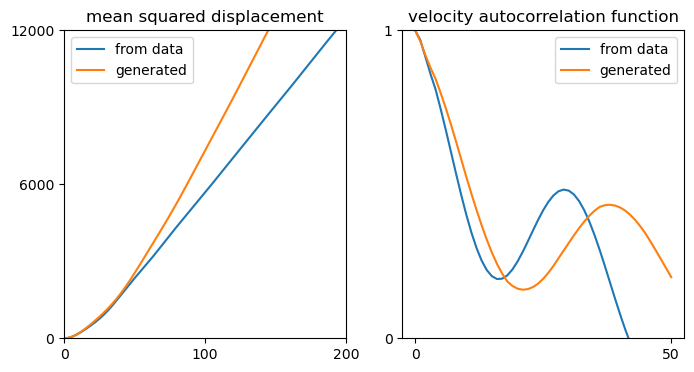

In [13]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(t_msd_data,msd_data,label='from data')
#ax[0].plot(t_msd_fft_data,msd_fft_data,label='data,fft')
#ax[1].plot(t_acf_data_pos,acf_data_pos,label='from data')
ax[1].plot(t_acf_data_vel,acf_data_vel,label='from data')

ax[0].plot(t_msd_simul,msd_simul,label='generated')
#ax[0].plot(t_msd_fft_simul,msd_fft_simul,label='simul,fft')
#ax[1].plot(t_acf_simul_pos,acf_simul_pos,label='generated')
ax[1].plot(t_acf_simul_vel,acf_simul_vel,label='generated')

#ax[1].set_yscale('log')
#ax[2].set_yscale('log')

for i in range(2):
    ax[i].legend()

ax[0].set_title('mean squared displacement')
ax[0].set_xlim(0,200)
ax[0].set_ylim(0,12000)

#ax[1].set_xlim(0,300)
ax[1].set_ylim(0,1)
#ax[1].set_title('positional autocorrelation function')

ax[1].set_title('velocity autocorrelation function')

ax[0].set_xticks([0,100,200])
ax[0].set_yticks([0,6000,12000])

ax[1].set_yticks([0,1])
ax[1].set_xticks([0,50])

fig.savefig('comparison_msd_acf.svg',bbox_inches='tight')